# LLM Exposure \& Supervision Exposure Construction
## LLM Exposure：
- E0: No exposure
- E1: Direct exposure
- E2: Exposure by LLM-powered applications
- E3: Exposure given image capabilities
- Annotation examples

## Supervision Exposure:
It is build on the work contexts and "job zones" in O*NET repository. Specifically,
- Communication: 1) Face-to-Face, 2) Public Speaking
- Responsibility: 1) Responsibility for outcomes, 2) Responsibility for others' health
- Physical Conditions: 1) Exposure to Outdoors Environments, 2) Physical Proxomoty to Others
- Criticality:1) Consequence of Errors, 2) Freedom of Decisions, 3) Frequency of Decisions
- Routine: i) Degree of Automation, 2) Unstructured vs Structured Work
- Skills: Job Zones

## Data
The data is gained from [O*NET Database](https://www.onetcenter.org/database.html): Work, worker characteristics and skill requirements across occupations, the dataframe here is compiled by merging those below and dropping tasks with no associated occupations and vice versa.
Specifically：
1. [Occupation Data](https://www.onetcenter.org/dl_files/database/db_27_1_text/Occupation%20Data.txt): The code, title, and description of each O*NET-SOC occupation. (This data is used in Data Processing.)
2. [Task Statements](https://www.onetcenter.org/dl_files/database/db_27_1_text/Task%20Statements.txt): The fields include: O\*NET-SOC Code, Task ID, Task, Task Type, Incumbents Responding, Date, and Domain Source. This primarily includes the task statements for each occupation, indicating whether the task is core or supplementary. Subsequent GPT scoring is based on the task statements in this table, followed by occupational-level aggregation based on the annotations for each task. (This data is used in LLM exposure costructing.)
3. [Task Weight](https://raw.githubusercontent.com/openai/GPTs-are-GPTs/refs/heads/main/data/full_onet_data.tsv): Tasks weights. This data is named full_onet_data as used below ("add in weights").
4. [Task Ratings](https://www.onetcenter.org/dl_files/database/db_27_2_text/Task%20Ratings.txt): For each task (Task ID) in each occupation, there are multiple scales for scoring and statistical metadata. This data is used in "add in weights".
5. [Work Context](https://www.onetcenter.org/dl_files/database/db_25_1_text/Work%20Context.txt)
6. [Job Zone](https://www.onetcenter.org/dl_files/database/db_29_2_text/Job%20Zones.txt)

Import packages

In [ ]:
import os
import json
import time
import argparse
import random
import pandas as pd
from typing import Dict, Any, Optional, List
from pydantic import BaseModel, Field
from tqdm import tqdm

from openai import OpenAI

import torch
from sentence_transformers import SentenceTransformer, util

## LLM Exposure construction

### Rubric

In [ ]:
SYSTEM_PROMPT = r"""
You are asked to assess whether a top‑tier LLM (2000‑word effective context, no reliable access to facts less than one year old unless explicitly supplied) can reduce the total time required to complete a given task by at least 50% while maintaining equivalent quality.

Assume you have average proficiency in the relevant role, access to the LLM via a standard interface (e.g., ChatGPT), and ordinary laptop tools (microphone, speakers, etc.). No other physical equipment or materials are available.

Please label the given task description  according to the taxonomy below:

## E0 - No exposure

Label E0 if direct use of the LLM cannot achieve the 50% time reduction threshold.
This includes tasks that inherently require physical presence, hands‑on manipulation, in‑person human interaction, or any non‑digital activity that cannot be substituted or accelerated by text or code based reasoning.

## E1 - Direct exposure

Label E1 if using the LLM alone (through a chat or playground interface) can already cut task time by at least half with comparable quality.
Typical E1‑eligible activities include:
(1)Writing or transforming text/code following complex instructions;
(2)Editing existing text/code according to specifications;
(3)Writing code to automate a previously manual procedure;
(4)Translating text between languages;
(5)Summarizing documents up to ~2000 words;
(6)Providing feedback on a document;
(7)Answering questions about a document’s content;
(8)Generating questions that a user might want to ask about a document

## E2 - Exposure through LLM‑powered applications

Label E2 if the LLM by itself does not yet cut task time by half, but one can easily imagine a software application built on top of the LLM that would achieve that reduction.
Such applications typically extend the LLM with capabilities like:
(1)Summarizing and querying documents longer than 2000 words;
(2)Retrieving up‑to‑date facts from the internet and combining them with LLM reasoning;
(3)Searching over an organization’s internal knowledge base, documents, or data.

Examples of such applications:
(1)A custom tool for a home goods company that processes internal data to support product/marketing decisions;
(2)A live suggestion system for customer service agents integrated into their call interface;
(3)Legal research software that aggregates past cases and drafts research memos;
(4)A grading assistant that applies a rubric to student essays and outputs letter grades;
(5)A multilingual news summarizer that retrieves current events and translates summaries.

## E3 - Exposure with image‑handling capabilities

Label E3 if the 50% time reduction becomes achievable once the LLM is paired with a system that can view, caption, and generate still images (but not video or highly precise measurements).
E3‑eligible image‑related tasks include:
(1)Reading and extracting text from PDFs or scanned documents;
(2)Scanning and interpreting information from images;
(3)Creating or editing digital images according to verbal/written instructions

## Annotation examples:

Occupation: Inspectors, Testers, Sorters, Samplers, and Weighers
Task: Adjust, clean, or repair products or processing equipment to correct defects found during inspections.
Label: E0
Explanation: The LLM has no physical embodiment; more than half of the task (adjusting, cleaning, repairing equipment) requires hands‑on manipulation or other physical activity.

Occupation: Computer and Information Research Scientists
Task: Apply theoretical expertise and innovation to create or apply new technology, such as adapting principles for applying computers to new uses.
Label: E1
Explanation: The model can draw on theoretical knowledge acquired during training, and the principles to be adapted can be conveyed through text input.

Activity: Schedule a dining reservation
Label: E2
Explanation: Automation for reservations already exists (e.g., Resy), and it is unclear what the LLM alone adds beyond that interface. However, one could easily build an application that lets a user ask the LLM to make a reservation via such a service.

Activity: Negotiate purchases or contracts
Label: E2
Explanation: Each party could transcribe its position, and an LLM could be used to reason about a resolution. Yet widespread adoption of such a system would require buy‑in from all parties, and the LLM alone does not cut negotiation time by half.

Occupation: Allergists and Immunologists
Task: Prescribe medication such as antihistamines, antibiotics, and nasal, oral, topical, or inhaled glucocorticosteroids.
Label: E2
Explanation: The LLM can suggest differential diagnoses and draft prescriptions and case notes. However, a human clinician must remain in the loop to exercise professional judgment and make the final prescribing decision.

Activity: Reading text from a scanned PDF
Label: E3
Explanation: The LLM alone cannot process image inputs. With a system that can perform OCR or extract text from images, the task can be completed significantly faster.

""".strip()

### ChatGPT label

In [ ]:
"""

Input:
Task Statements.txt

Output: task_scores.csv

"""

"Please replace the path of the corresponding file"

TASK_STATEMENTS_PATH = r"Task Statements.txt"
OUTPUT_PATH = r"task_scores.csv"
MODEL = "gpt-4o-mini"        
BATCH_SIZE = 20             
SAVE_EVERY_BATCHES = 20      
SLEEP_BETWEEN_CALLS = 0.0    
MAX_ROWS = None              
TEMPERATURE = 0.0
MAX_RETRIES = 6

class LLM_Exposure(BaseModel):
    label: str = Field(..., description = "One of E0/E1/E2/E3")


class TaskItem(BaseModel):
    task_key: str
    llm_exposure: LLM_Exposure

class TaskBatchRating(BaseModel):
    items: List[TaskItem]


def load_tasks(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep = "\t", dtype = str, keep_default_na = False)
    df["task_key"] = df["O*NET-SOC Code"].astype(str) + "::" + df["Task ID"].astype(str)
    return df

def build_batch_prompt(chunk: pd.DataFrame) -> str:
    """
    Feed a JSON list of tasks to be rated. Model must return a list with same task_key.
    """
    payload = [
        {"task_key": row["task_key"], "task": row["Task"]}
        for _, row in chunk.iterrows()
    ]
    return (
        "Rate EACH task independently. Return results for ALL items.\n"
        "Only provide LLM exposure label: one of E0/E1/E2/E3.\n"
        "IMPORTANT: Preserve task_key exactly as given.\n\n"
        "TASKS_JSON:\n"
        + json.dumps(payload, ensure_ascii=False)
    )

def call_model_batch(client: OpenAI, model: str, user_text: str, temperature: float = 0.0, max_retries: int = 6) -> TaskBatchRating:
    for attempt in range(1, max_retries + 1):
        try:
            completion = client.chat.completions.parse(
                model=model,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": user_text},
                ],
                response_format=TaskBatchRating,
                temperature=temperature,
            )

            return completion.choices[0].message.parsed
        except Exception as e:
            print(f"Error: {e}")
    raise RuntimeError


def run_scoring_batched(task_path: str, output_path: str, model: str, sleep: float = 0.0, max_rows=None, save_every: int = 50):

    "Please use your own API key"
    client = OpenAI()

    df = load_tasks(task_path)
    done_keys = set()  

    if os.path.exists(output_path):
        try:
            prev = pd.read_csv(output_path, usecols=["task_key"], dtype=str)
            done_keys = set(prev["task_key"].astype(str).tolist())
        except Exception:
            done_keys = set()
    else:
        pd.DataFrame(columns=["task_key", "LLM_Exposure_Label"]).to_csv(output_path, index=False)

    # Filtering incomplete
    df = df[~df["task_key"].isin(done_keys)].copy()
    buffer_rows = []
    save_threshold = BATCH_SIZE * SAVE_EVERY_BATCHES

    n = len(df)
    for start in tqdm(range(0, n, BATCH_SIZE)):
        chunk = df.iloc[start:start + BATCH_SIZE]
        user_text = build_batch_prompt(chunk)

        try:
            rated = call_model_batch(
                client = client,
                model = model,
                user_text = user_text,
                temperature = TEMPERATURE,
                max_retries = MAX_RETRIES
            )

            got = {it.task_key: it for it in rated.items}

            for key in chunk["task_key"].astype(str).tolist():
                it = got.get(key, None)
                if it is None:
                    buffer_rows.append({
                        "task_key": key,
                        "LLM_Exposure_Label": ""
                    })
                else:
                    buffer_rows.append({
                        "task_key": key,
                        "LLM_Exposure_Label": it.llm_exposure.label
                    })

        except Exception as e:
            print("Batch error:", repr(e))
            for key in chunk["task_key"].astype(str).tolist():
                buffer_rows.append({
                    "task_key": key,
                    "LLM_Exposure_Label": ""
                })

        if len(buffer_rows) >= save_threshold:
            out_df = pd.DataFrame(buffer_rows)
            out_df.to_csv(output_path, mode="a", header=False, index=False)
            done_keys.update(out_df["task_key"].astype(str).tolist())
            buffer_rows = []


    if buffer_rows:
        out_df = pd.DataFrame(buffer_rows)
        out_df.to_csv(output_path, mode="a", header=False, index=False)
        done_keys.update(out_df["task_key"].astype(str).tolist())


In [ ]:
run_scoring_batched(
    task_path=TASK_STATEMENTS_PATH,
    output_path=OUTPUT_PATH,
    model=MODEL,
    max_rows=MAX_ROWS,
    save_every=50
)

## Supervision exposure construction

In [ ]:
import pandas as pd
import re
import numpy as np

"Please replace the path of the corresponding file"

WORK_CONTEXT_PATH = "Work Context.xlsx"
JOB_ZONES_PATH = "Job Zones.xlsx"

df_work_context = pd.read_excel(WORK_CONTEXT_PATH)
df_job_zones = pd.read_excel(JOB_ZONES_PATH)


In [ ]:
df_work_context = df_work_context[["O*NET-SOC Code", "Title", "Element ID", "Element Name" ,"Scale ID", "Data Value"]].copy()
df_work_context["Data Value"] = pd.to_numeric(df_work_context['Data Value'], errors = "coerce")
df_job_zones['Job Zone'] = pd.to_numeric(df_job_zones['Job Zone'], errors = "coerce")

# Since we only use the value of the variable with Scale ID CX in work_context, we filter accordingly.
df_work_context = df_work_context[df_work_context["Scale ID"] == "CX"].reset_index(drop = True).copy()

# List of variables used for scoring
work_context_list = ["Face-to-Face Discussions","Public Speaking","Responsibility for Outcomes and Results","Responsible for Others' Health and Safety","Physical Proximity","Outdoors, Exposed to Weather","Consequence of Error"
                     ,"Frequency of Decision Making","Freedom to Make Decisions","Degree of Automation","Structured versus Unstructured Work"]
df_work_context = df_work_context[df_work_context["Element Name"].isin(work_context_list)]

# The automation score is inverted 
mask_auto = df_work_context["Element Name"].eq("Degree of Automation")
df_work_context.loc[mask_auto, "Data Value"] = -df_work_context.loc[mask_auto, "Data Value"]

"""
The average value is calculated as follows: 
the scores in `work_context` are continuous variables from 0 to 5, while the scores in `job_zone` are discrete variables from 1 to 5. 
The weighting method is the arithmetic mean; the arithmetic mean is then divided by 5 to ensure the final value ranges from (0,1).
"""
df_wc_wide = (
    df_work_context.pivot_table(index = ["O*NET-SOC Code", "Title"], columns = "Element Name", values="Data Value", aggfunc="mean")
    .reset_index()
)
df_wc_wide = pd.merge(df_wc_wide, df_job_zones, on = ['O*NET-SOC Code'])
cols = ["Face-to-Face Discussions","Public Speaking","Responsibility for Outcomes and Results",
        "Responsible for Others' Health and Safety","Physical Proximity","Outdoors, Exposed to Weather",
        "Consequence of Error","Frequency of Decision Making","Freedom to Make Decisions",
        "Degree of Automation","Structured versus Unstructured Work","Job Zone"]

df_wc_wide["supervision_exposure"] = df_wc_wide[cols].mean(axis=1, skipna=True) / 5.0


## Add in weights

We consider Three different weightings for tasks within an occupation:
- Importance: IM weights from O*NET

- Core: Core vs. supplemental labels from O*NET. Core gets twice the weight of Supplemental. Missing values default to supplemental.

- Equal: Equal weight over all tasks in an occupation.

In [ ]:
df_tasks = pd.read_csv("full_onet_data.txt",sep='\t', header=None)

df_tasks_columns = df_tasks.iloc[0]
df_tasks.columns = df_tasks_columns
df_tasks = df_tasks[1:]
df_tasks["Task ID"] = df_tasks["Task ID"].astype(str)
df_tasks = df_tasks.iloc[:,1:]


In [ ]:
"""
Build occupation-level exposure measure form task-level GPT ratings

Inputs:
1) Task Statements.txt
2) task_score.csv (GPT-scoring)
3) Task Ratings.txt (tab-separated) for IM importance weights

Output:
occupation_exposure.csv

Main outputs (occupation-level):
  - alpha_E1: weighted share of E1 tasks
  - beta_E1_plus_halfE2: alpha + 0.5*share(E2/E3)
  - zeta_E1_plus_E2: alpha + share(E2/E3)
  - S_mean: weighted mean of S (S0=0..S3=3)
  - S_share_S2S3, S_share_S3
"""

alpha_llm_score_map = {"E0": 0.0, "E1": 1.0, "E2": 0.0, "E3": 0.0}
beta_llm_score_map = {"E0": 0.0, "E1": 1.0, "E2": 0.5, "E3": 0.5}
gamma_llm_score_map = {"E0": 0.0, "E1": 1.0, "E2": 1.0, "E3": 1.0}

full_labels = pd.read_csv("task_scores.csv")

# The O*NET-SOC Code and Task ID need to be extracted based on the task_key.
full_labels["O*NET-SOC Code"] = full_labels['task_key'].apply(lambda x: x[:10])
full_labels["Task ID"] = full_labels['task_key'].apply(lambda x: x[12:])

# Convert the labels into numbers according to the original definition.
full_labels["llm_exposure_alpha"] = full_labels['LLM_Exposure_Label'].apply(lambda x: alpha_llm_score_map[x])
full_labels["llm_exposure_beta"] = full_labels['LLM_Exposure_Label'].apply(lambda x: beta_llm_score_map[x])
full_labels["llm_exposure_gamma"] = full_labels['LLM_Exposure_Label'].apply(lambda x: gamma_llm_score_map[x])

df_tasks = pd.read_csv("full_onet_data.txt",sep='\t', header=None)
new_header = df_tasks.iloc[0]
df_tasks = df_tasks[1:] 
df_tasks.columns = new_header

df_tasks["Task ID"] = df_tasks["Task ID"].apply(lambda x: x[:-2]).astype(str)
df_tasks = df_tasks.iloc[:,1:]

# converting the core / supplemental rating to a numerical weight where core is worth 2x the taskweight of a supplemental task.
df_tasks["coreweight"] = df_tasks["Task Type"].map(
    {"Core": 2, "Supplemental": 1, np.nan: 1}
)
df_tasks["equalweight"] = df_tasks["Task Type"].map(
    {"Core": 1, "Supplemental": 1, np.nan: 1}
)

df_taskratings = pd.read_csv("/Users/weichenyang/Desktop/科研/科研_修改/Task Ratings.txt",sep='\t', header=None)
new_header_1 = df_taskratings.iloc[0]
df_taskratings = df_taskratings[1:]
df_taskratings.columns = new_header_1
df_taskratings_relevant = df_taskratings[df_taskratings["Scale ID"].isin(["RT", "IM"])][
    ["O*NET-SOC Code", "Task ID", "Scale ID", "Data Value"]
]

dfr_taskratings = pd.pivot(
    df_taskratings_relevant, index=["O*NET-SOC Code", "Task ID"], columns=["Scale ID"]
).reset_index()
dfr_taskratings.columns = ["O*NET-SOC Code", "Task ID", "importance", "relevance"]
task_tmp = pd.merge(df_tasks, dfr_taskratings, how="left")
task_tmp["importance"] = task_tmp["importance"].astype(float)
task_tmp["relevance"] = task_tmp["relevance"].astype(float)
task_tmp["coreweight"] = task_tmp["coreweight"].astype(float)
task_tmp["equalweight"] = task_tmp["equalweight"].astype(float)


In [ ]:
impWeightOcc = (
    task_tmp[["O*NET-SOC Code", "importance", "relevance", "coreweight", "equalweight"]]
    .groupby("O*NET-SOC Code")
    .sum()
    .reset_index()
)
impWeightOcc.rename(
    columns={
        "importance": "impTotal",
        "relevance": "relTotal",
        "coreweight": "coreweightTotal",
        "equalweight": "equalweightTotal",
    },
    inplace=True,
)
task_tmp_weighted = pd.merge(task_tmp, impWeightOcc, how="left", on="O*NET-SOC Code")
task_tmp_weighted["importance_weight"] = (
    task_tmp_weighted["importance"].astype(float) / task_tmp_weighted["impTotal"].astype(float)
)
task_tmp_weighted["relevance_weight"] = (
    task_tmp_weighted["relevance"].astype(float) / task_tmp_weighted["relTotal"].astype(float)
)
task_tmp_weighted["core_weight"] = (
    task_tmp_weighted["coreweight"].astype(float) / task_tmp_weighted["coreweightTotal"].astype(float)
)
task_tmp_weighted["equal_weight"] = (
    task_tmp_weighted["equalweight"].astype(float) / task_tmp_weighted["equalweightTotal"].astype(float)
)

for d in (full_labels, task_tmp_weighted):
    d["O*NET-SOC Code"] = d["O*NET-SOC Code"].astype(str).str.strip()
    d["Task ID"] = d["Task ID"].astype(str).str.strip()

In [ ]:
full_labels_weight = pd.merge(
    full_labels.drop(columns=["task_key"], errors="ignore"),
    task_tmp_weighted[
        [
            "O*NET-SOC Code",
            "Task ID",
            "importance_weight",
            "relevance_weight",
            "core_weight",
            "equal_weight",
        ]
    ],
    how="left",
)

weight_list = ["core_weight", "equal_weight"]
exposures_list = [
    "llm_exposure_alpha", "llm_exposure_beta", "llm_exposure_gamma",
]
# groupfields is grouping criteria; aggfields are variables to be aggregated; weightfield are weight variables.
def weighted_mean(df, groupfields, aggfields, weightfield): 
    w = df[weightfield].astype(float)
    num = df[aggfields].mul(w, axis=0) 

    tmp = pd.concat([df[groupfields], num, w.rename("__w__")], axis=1)
    g = tmp.groupby(groupfields, dropna=False)

    denom = g["__w__"].sum()
    out = g[aggfields].sum().div(denom, axis=0)

    out = out.reset_index()
    return out

results = []
for w in weight_list:
    occ = weighted_mean(full_labels_weight, ["O*NET-SOC Code"], exposures_list, w)
    occ = occ.rename(columns={e: f"{e}_{w}" for e in exposures_list})
    results.append(occ)

occupation_exposure = results[0]
for i in range(1, len(results)):
    occupation_exposure = occupation_exposure.merge(results[i], on="O*NET-SOC Code", how="outer")


final_exposure = occupation_exposure.merge(df_wc_wide, on = ["O*NET-SOC Code"], how = "inner")
final_exposure = final_exposure[['O*NET-SOC Code', 'llm_exposure_alpha_core_weight',
       'llm_exposure_beta_core_weight', 'llm_exposure_gamma_core_weight',
       'llm_exposure_alpha_equal_weight', 'llm_exposure_beta_equal_weight',
       'llm_exposure_gamma_equal_weight', 'supervision_exposure']]

final_exposure.to_csv("occupation_exposure.csv")

# Data Processing

Based on the job description in the recruitment information, we performed a brief processing and then used text analysis to match it with the six-digit job description at the O*NET-SOC code level. The specific steps were:

- Prepare the O*NET reference table

- Preprocess the Chinese JD description

- Perform vector retrieval (Top-K) using multilingual embeddings

- Perform class consistency voting: Identify the two-digit code that appears most frequently in the Top-K, obtaining `major2_hat` and the "concentration index" `major_share`

- Select the soc6 with the highest similarity from the `major2_hat` subset as `soc6_hat`

- Backfill into the JD description

## Data
- The empirical analysis in this paper relies on a large-scale dataset constructed from online recruitment postings. 

- Due to the proprietary nature of the raw online job postings, the platforms' Terms of Service (ToS) strictly prohibiting the public redistribution of scraped text, and the prohibitive file size of the raw files (exceeding 10 GB), the raw scraped dataset is not included in this public replication package.

In [ ]:
POSTINGS_FILE = ""
ONET_OCC_FILE = "Occupation Data.txt"
OUT_DIR = ""

"If you want to run this programme offline, please include MODEL_PATH correctly."
MODEL_PATH = "mini_lm_model"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# Map the SOC code from six digits to two digits and construct the text for matching
# 11-1011.00 -> 11
def soc6_to_major2(soc6: str) -> str:
    if pd.isna(soc6): 
        return np.nan
    s = str(soc6)
    return s.split("-")[0] if "-" in s else np.nan

df_occ = pd.read_csv(ONET_OCC_FILE, sep = '\t', header = 0)  
df_occ["major2"] = df_occ["O*NET-SOC Code"].apply(soc6_to_major2)

# Build reference text for matching: Title + Description
ref = df_occ["Title"].fillna("").astype(str)
ref = ref + ":" + df_occ["Description"].fillna("").astype(str)
df_occ["text_ref"] =  ref.str.replace(r"\s+", " ", regex=True).str.strip().str.lower()

## Clean up JD and retain useful information

In [ ]:
'''
Clean up JD and retain useful information.
'''
import hashlib
_RX_BRACKETS = re.compile(r"[\(\（\[].*?[\)\）\]]")
_RX_SPACES = re.compile(r"\s+")
_RX_NOISE = re.compile(
    r"(急招|高薪|双休|五险一金|包吃|包住|可实习|应届|校招|社招|"
    r"北京|上海|深圳|广州|杭州|南京|武汉|成都|重庆|苏州|西安|天津|"
    r"（.*?）|\(.*?\))",
    flags=re.IGNORECASE,
)

_BOILER = [
    "岗位职责", "工作职责", "职位描述", "岗位描述", "工作内容", "主要职责",
    "任职要求", "岗位要求", "职位要求", "任职资格", "任职条件",
    "福利待遇", "薪酬福利", "工作地点", "公司简介", "岗位介绍"
]
_RX_BOILER = re.compile("|".join(map(re.escape, _BOILER)))
_RX_HTML = re.compile(r"<[^>]+>")
_RX_URL  = re.compile(r"(https?://\S+|www\.\S+)")
_RX_EMAIL= re.compile(r"[\w\.-]+@[\w\.-]+\.\w+")
_RX_PHONE= re.compile(r"1\d{10}")

def to_halfwidth(s: str) -> str:
    if s is None: return ""
    res = []
    for ch in str(s):
        code = ord(ch)
        if code == 0x3000:
            code = 0x20
        elif 0xFF01 <= code <= 0xFF5E:
            code -= 0xFEE0
        res.append(chr(code))
    return "".join(res)

def clean_title(t: str) -> str:
    if pd.isna(t): return ""
    s = to_halfwidth(str(t)).strip()
    s = _RX_BRACKETS.sub(" ", s)
    s = _RX_NOISE.sub(" ", s)
    s = re.sub(r"[·•/\\|]", " ", s)
    s = re.sub(r"[\-_—–]", " ", s)
    s = re.sub(r"[^\w\u4e00-\u9fff ]+", " ", s)
    s = _RX_SPACES.sub(" ", s).strip().lower()
    return s


def clean_description(text: str, max_chars: int = 800) -> str:
    s = to_halfwidth(text)
    s = _RX_HTML.sub(" ", s)
    s = _RX_URL.sub(" ", s)
    s = _RX_EMAIL.sub(" ", s)
    s = _RX_PHONE.sub(" ", s)
    s = s.replace("\u3000", " ").replace("\xa0", " ")
    s = _RX_BOILER.sub(" ", s)
    s = re.sub(r"[■★●◆◎◇▶▷]", " ", s)
    s = _RX_SPACES.sub(" ", s).strip().lower()
    return s[:max_chars]

# Each posting is assigned a number based on the cleaned text, using the text's hash.
def sha1_hex(s: str) -> str:
    b = str(s).encode("utf-8", errors="ignore")
    return hashlib.sha1(b).hexdigest()

USE_COLS = ['关联股票代码','招聘发布年份','企业名称','上市公司行业','工作城市',
            '招聘岗位','职位描述','招聘类别','招聘人数','学历要求','要求经验','最低月薪','最高月薪']

def get_use_df(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in USE_COLS if c in df.columns]
    return df[existing].copy()

# Get the Chinese text and ID to be matched.
def build_query_and_id(df: pd.DataFrame) -> pd.DataFrame:
    df["query_text"] = (
        df["招聘岗位"].fillna("").astype(str).map(clean_title)
        + " : "
        + df["职位描述"].fillna("").astype(str).map(lambda x: clean_description(x, 800))
    ).str.strip()
    df = df[df["query_text"].str.len() > 0].copy()
    df["unique_id"] = df["query_text"].map(sha1_hex)
    return df

## Top-K search

In [ ]:
'''
Top-K search, because it involves cross-language matching, uses SentenceTransformer.
'''
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)
MODEL_PATH = "mini_lm_model"
model = SentenceTransformer(MODEL_PATH, device=device)
years = list(range(2016,2026))

occ_emb = model.encode(
        df_occ["text_ref"].tolist(),
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True
    )

for y in years:
    file_path = os.path.join(POSTINGS_FILE, f"y}.csv")
    df_post = pd.read_csv(file_path, low_memory=False)
    df_post = get_use_df(df_post)
    df_post = build_query_and_id(df_post)
    df_q = df_post[["unique_id", "query_text"]].drop_duplicates().reset_index(drop=True)

    qry_emb = model.encode(
        df_q["query_text"].tolist(),
        batch_size=2048 if device=="cuda" else 256,
        show_progress_bar=True,
        normalize_embeddings=True
        )

    hits = util.semantic_search(
        qry_emb, occ_emb,
        top_k=1,
        score_function=util.dot_score
    )

    top1_idx = np.array([h[0]["corpus_id"] for h in hits], dtype=np.int32)
    df_q["soc6_hat"] = df_occ["O*NET-SOC Code"].iloc[top1_idx].values

    df_post = df_post.merge(df_q[["unique_id", "soc6_hat"]], on="unique_id", how="left")

    KEEP_COLS = [
    '关联股票代码','招聘发布年份','企业名称','上市公司行业','工作城市',
    '招聘岗位','招聘人数','学历要求','要求经验','最低月薪','最高月薪',
    'unique_id','soc6_hat']

    df_post_out = df_post[KEEP_COLS].copy()
    df_post_out.to_csv(os.path.join(OUT_DIR, f"unique_query_soc6_map_{y}.csv"), index=False, encoding="utf-8-sig")



Further data processing is required:

- Combine the obtained postings with company characteristics

- Combine occupation type with various exposure levels

- Data of company characteristics could be seen in the uploaded file firms.csv

In [ ]:
"""
put all the job postings together
"""
import pandas as pd
years = list(range(2017,2026))

final_data = pd.DataFrame()
for y in years:
    path = f"{y}_postings.csv"
    data = pd.read_csv(path)
    final_data = pd.concat([final_data, data])

final_data = final_data.rename(columns={"关联股票代码": "stkcd", "招聘发布年份": "year"})
final_data = final_data[~final_data["stkcd"].isna()]
final_data['stkcd'] = final_data['stkcd'].apply(lambda x: str(int(x)))
final_data['year'] = final_data['year'].apply(lambda x: str(int(x)))

In [ ]:
# firms.csv contains variables related to listed companies.
firms_df = pd.read_csv("firms.csv")
firms_df["stkcd"] = firms_df["stkcd"].astype(str)
firms_df["year"]  = pd.to_numeric(firms_df["year"], errors="coerce").astype("Int64")

years = list(range(2017, 2026))
stkcd_year_combinations = (
    final_data[["stkcd"]].drop_duplicates()
    .assign(key=1)
    .merge(pd.DataFrame({"year": years, "key": 1}), on="key")
    .drop("key", axis=1)
)
stkcd_year_combinations["year"] = stkcd_year_combinations["year"].astype("Int64")

merged_full = pd.merge(stkcd_year_combinations, firms_df, on=["stkcd", "year"], how="left")

FIRM_VARS = ["员工总数", "人均创收万元", "人均创利万元", "本科学历占比", "IndustryName", "PROVINCE"]
fill_cols = [c for c in FIRM_VARS if c in merged_full.columns]

# First sort by stkcd-year, then within the group, use ffill + bfill (most recent year).）
merged_full = merged_full.sort_values(["stkcd", "year"])
merged_full[fill_cols] = (
    merged_full.groupby("stkcd", sort=False)[fill_cols]
    .transform(lambda s: s.ffill().bfill())
)


In [ ]:
# The final compiled postings are then processed: the number of positions to be filled and the monthly salary are calculated.
def parse_headcount(s):
    if pd.isna(s):
        return np.nan, True, False  # value, is_missing, is_unspecified

    s0 = str(s).strip()
    if s0 == "":
        return np.nan, True, False

    # Standardize some symbols
    s0 = s0.replace("～", "~").replace("−", "-").replace("—", "-").replace("－", "-")
    s0 = s0.replace("至", "~").replace("到", "~").replace(" ", "")

    if "若干" in s0:
        return np.nan, False, True

    nums = [int(x) for x in re.findall(r"\d+", s0)]
    if len(nums) == 0:
        return np.nan, True, False

    if ("~" in s0 or "-" in s0) and len(nums) >= 2:
        return (nums[0] + nums[1]) / 2.0, False, False
    
    return float(nums[0]), False, False

df = final_data.copy()
parsed = df["招聘人数"].apply(parse_headcount)
df["recruit_num"] = parsed.apply(lambda x: x[0])
df["is_missing_recruitnum"] = parsed.apply(lambda x: x[1]).astype(int)
df["is_unspecified_recruitnum"] = parsed.apply(lambda x: x[2]).astype(int)

group_keys = ["stkcd", "year"]  
df["recruit_num"] = df["recruit_num"].fillna(
    df.groupby(group_keys)["recruit_num"].transform("median")
)

df["recruit_num"] = df["recruit_num"].fillna(1.0)
final_data = df[['stkcd', 'year', '企业名称', '上市公司行业', '招聘岗位', '学历要求',
       '要求经验', '最低月薪', '最高月薪', 'unique_id', 'soc6_hat', 'recruit_num']]


In [ ]:
cols = ["最低月薪", "最高月薪"]
final_data[cols] = (
    final_data[cols].astype("string")
    .replace({ "—": "-", "－": "-", "−": "-", "–": "-" }, regex=False)
    .replace(r"^\s*-\s*$", pd.NA, regex=True)
)

final_data[cols] = final_data[cols].apply(pd.to_numeric, errors="coerce")

final_data.loc[final_data["最低月薪"] == 0, "最低月薪"] = np.nan
final_data.loc[final_data["最高月薪"] == 0, "最高月薪"] = np.nan
low  = final_data["最低月薪"].astype(float).to_numpy()
high = final_data["最高月薪"].astype(float).to_numpy()

swap = np.isfinite(low) & np.isfinite(high) & (low > high)
low2  = low.copy()
high2 = high.copy()
low2[swap], high2[swap] = high2[swap], low2[swap]

salary = np.where(np.isfinite(low2) & np.isfinite(high2), (low2 + high2) / 2,
          np.where(np.isfinite(low2), low2,
          np.where(np.isfinite(high2), high2, np.nan)))

final_data["月薪"] = salary


In [ ]:
# Merge final_data with exposure
final_data = final_data.rename(columns={'soc6_hat':"O*NET-SOC Code"})
exposure_table = pd.read_csv("/Users/weichenyang/Desktop/科研/科研_修改/occupation_exposure.csv")
final_data = pd.merge(final_data, exposure_table, on = "O*NET-SOC Code", how = "inner")

# Based on the O*NET-SOC Code, the two-digit code of O*NET is obtained, and thus, the labor force is divided into four types.
final_data["标准职业分类代码"] = final_data["O*NET-SOC Code"].apply(lambda x: x[:2])
labor_type_map = {"11":"非常规认知","13":"非常规认知","15":"非常规认知","17":"非常规认知","19":"非常规认知","21":"非常规认知","23":"非常规认知","25":"非常规认知","27":"非常规认知","29":"非常规认知",
                  "31":"非常规体力","33":"非常规体力","35":"非常规体力","37":"非常规体力","39":"非常规体力",
                  "41":"常规认知","43":"常规认知",
                  "47":"常规体力","49":"常规体力","51":"常规体力","53":"常规体力"}

soc2 = final_data["标准职业分类代码"].astype("string")
final_data["labor_type"] = soc2.map(labor_type_map)

In [10]:
final_data_use = final_data[['stkcd', 'year', '企业名称', '上市公司行业',
       'unique_id', 'O*NET-SOC Code', 'recruit_num', '月薪',
       'llm_exposure_alpha_core_weight', 'llm_exposure_beta_core_weight',
       'llm_exposure_gamma_core_weight',
       'llm_exposure_alpha_equal_weight', 'llm_exposure_beta_equal_weight',
       'llm_exposure_gamma_equal_weight', 'supervision_exposure',
       '标准职业分类代码', 'labor_type']]

In [ ]:
final_data.to_csv("final_data.csv")

In [ ]:
final_data_use.to_csv("final_data_use.csv")

## Aggregate data to the posting-year-labor type level.


In [ ]:
import pandas as pd
import numpy as np

LLM_exposure_cols  = [
    "llm_exposure_alpha_core_weight","llm_exposure_beta_core_weight","llm_exposure_gamma_core_weight",
    "llm_exposure_alpha_equal_weight","llm_exposure_beta_equal_weight","llm_exposure_gamma_equal_weight"
]

sup_col = ["supervision_exposure"] 
group_soc = ["stkcd", "year", "labor_type", "O*NET-SOC Code"]   
group_lt  = ["stkcd", "year", "labor_type"] 

expo_cols = LLM_exposure_cols 
group_keys = ["stkcd", "year", "labor_type"]

final_data_use["recruit_num"] = pd.to_numeric(final_data_use["recruit_num"], errors="coerce").fillna(1.0)
final_data_use[expo_cols] = final_data_use[expo_cols].apply(pd.to_numeric, errors="coerce")
final_data_use["月薪"] = pd.to_numeric(final_data_use["月薪"], errors="coerce")

final_data_use[LLM_exposure_cols] = final_data_use[LLM_exposure_cols].apply(pd.to_numeric, errors="coerce")
final_data_use[sup_col] = final_data_use[sup_col].apply(pd.to_numeric, errors="coerce")

static_supervision_exposure = final_data_use.groupby("labor_type")[sup_col].mean().reset_index()

t = final_data_use.set_index(group_keys)

w = t["recruit_num"].astype(float)

base = t.groupby(level=group_keys, dropna=False).agg(
    recruit_total=("recruit_num", "sum"),
    n_postings=("unique_id", "nunique")
)

num = t[expo_cols].fillna(0).mul(w, axis=0).groupby(level=group_keys, dropna=False).sum()
den = t[expo_cols].notna().mul(w, axis=0).groupby(level=group_keys, dropna=False).sum()
means = num.div(den)

df_out = base.join(means).reset_index() 

wage_num = (t["月薪"].fillna(0) * w).groupby(level=group_keys, dropna=False).sum()
wage_den = (t["月薪"].notna() * w).groupby(level=group_keys, dropna=False).sum()
wage_mean = (wage_num / wage_den).rename("wage_mean").reset_index()

df_out = df_out.merge(wage_mean, on=group_keys, how="left")
df_out = df_out.merge(static_supervision_exposure, on = ["labor_type"], how = 'left')

df_out["firmyear_total"] = df_out.groupby(["stkcd", "year"])["recruit_total"].transform("sum")
df_out["share"] = df_out["recruit_total"] / df_out["firmyear_total"]
df_out["stkcd"] = df_out['stkcd'].astype(str)

firms_df = merged_full
firms_df["stkcd"] = firms_df["stkcd"].astype(str)
firms_df["year"]  = pd.to_numeric(firms_df["year"], errors="coerce").astype("Int64")

firms_df_merge = firms_df[["stkcd","year","员工总数","人均创收万元","人均创利万元","本科","本科学历占比","IndustryName","PROVINCE","总收入","总利润"]].copy()

firm_level_data = pd.merge(df_out, firms_df_merge, on = ["stkcd","year"], how = "left")

In [ ]:
firm_level_data.to_csv("firm_labortype_level_data.csv")

# Plot


/var/folders/ww/xth5wlyd0_lc0plrkfzcqknc0000gn/T/ipykernel_61255/1001869620.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


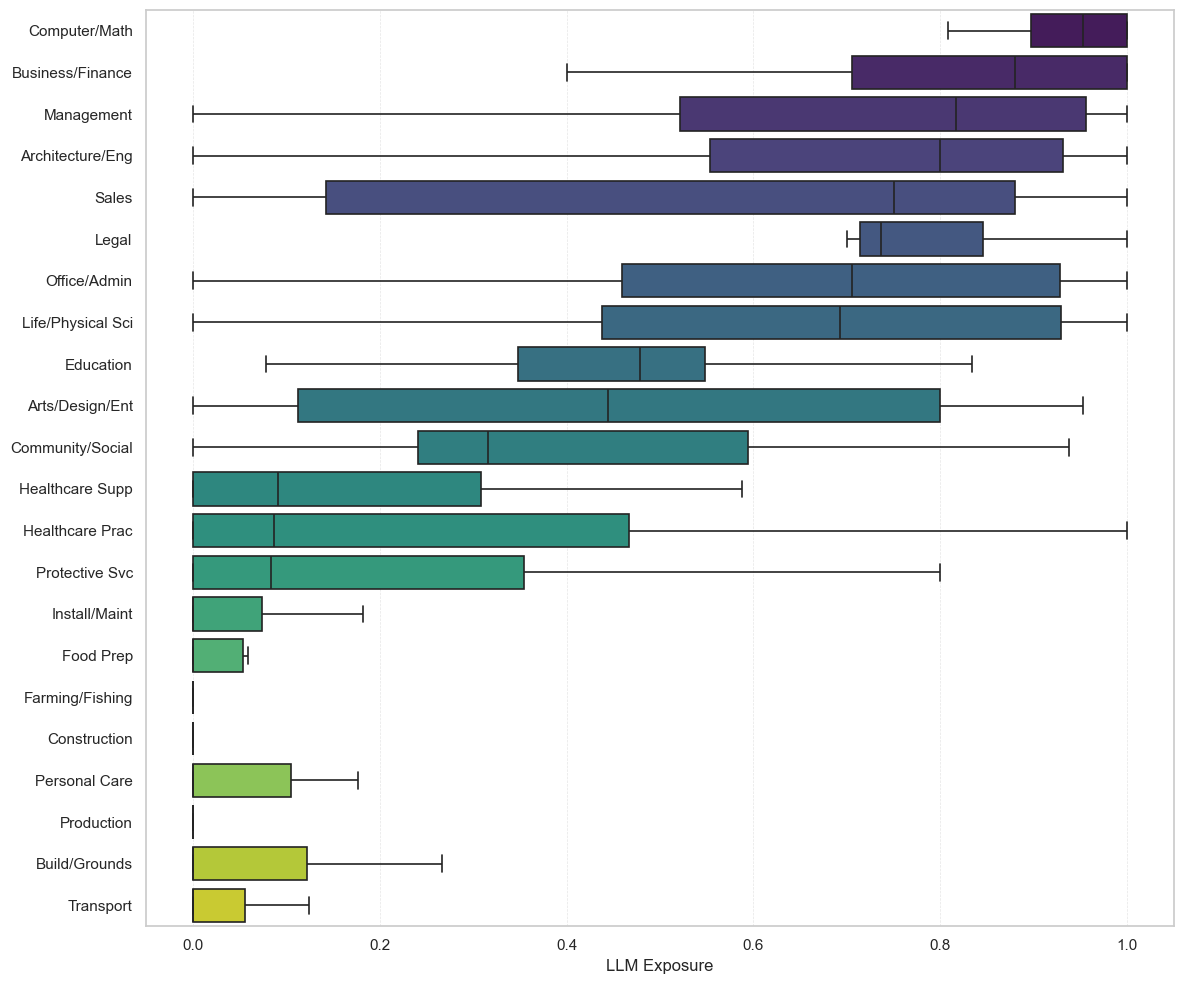

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

df = pd.read_csv('/Users/weichenyang/Desktop/科研/科研_修改/occupation_exposure.csv')

# Extracting 2 digit SOC-code
df['Major_Group_Code'] = df['O*NET-SOC Code'].astype(str).str[:2]

soc_major_groups = {
    '11': 'Management', '13': 'Business/Finance', '15': 'Computer/Math',
    '17': 'Architecture/Eng', '19': 'Life/Physical Sci', '21': 'Community/Social',
    '23': 'Legal', '25': 'Education', '27': 'Arts/Design/Ent',
    '29': 'Healthcare Prac', '31': 'Healthcare Supp', '33': 'Protective Svc',
    '35': 'Food Prep', '37': 'Build/Grounds', '39': 'Personal Care',
    '41': 'Sales', '43': 'Office/Admin', '45': 'Farming/Fishing',
    '47': 'Construction', '49': 'Install/Maint', '51': 'Production', '53': 'Transport'
}
df['Major_Group_Name'] = df['Major_Group_Code'].map(soc_major_groups)
df = df.dropna(subset=['Major_Group_Name'])

llm_col = 'llm_exposure_gamma_core_weight' # LLM Exposure
plt.figure(figsize=(12, 10))

median_exposure = df.groupby('Major_Group_Name')[llm_col].median().sort_values(ascending=False)
sorted_order = median_exposure.index

sns.boxplot(
    data=df,
    x=llm_col,
    y='Major_Group_Name',
    order=sorted_order,
    palette='viridis',
    linewidth=1.2,
    fliersize=0
)

plt.xlabel('LLM Exposure', fontsize=12)
plt.ylabel('') 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

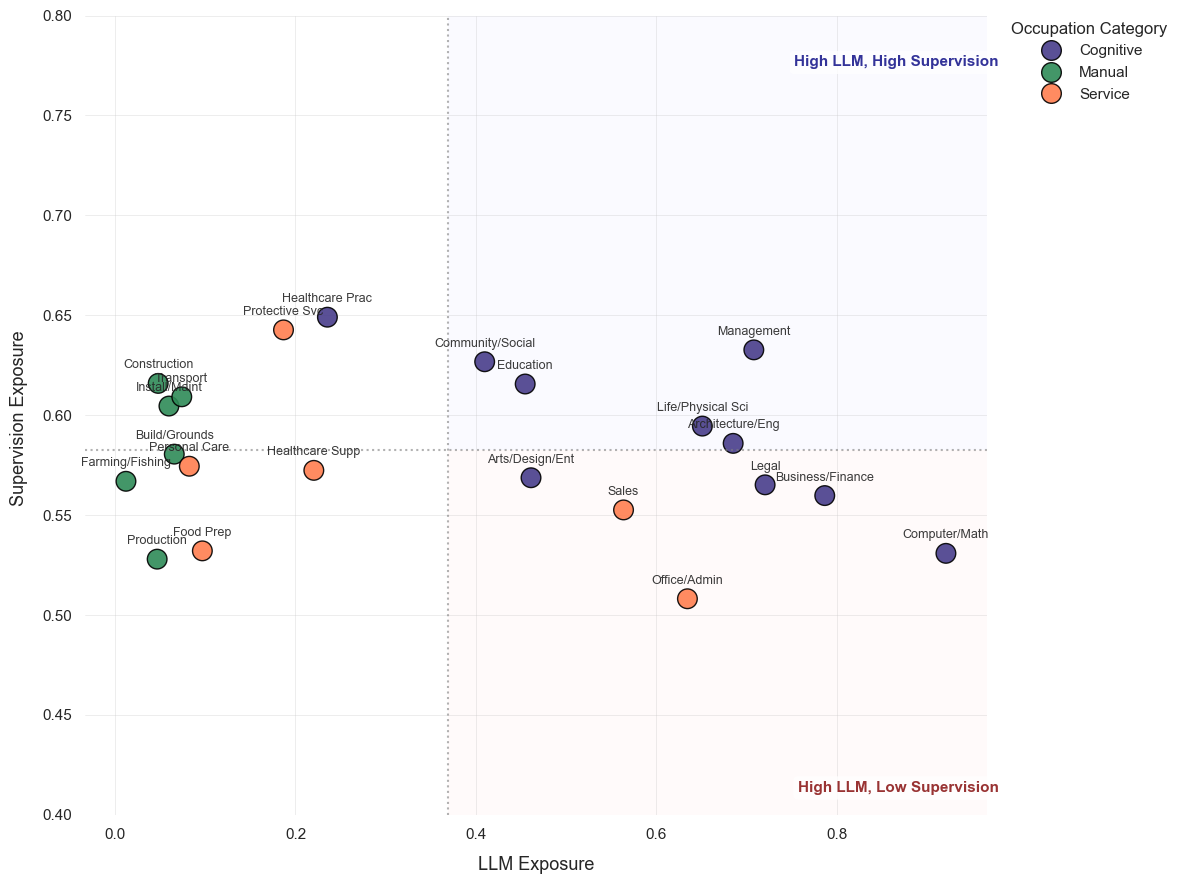

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches


df = pd.read_csv('/Users/weichenyang/Desktop/科研/科研_修改/occupation_exposure.csv')
df['Major_Group_Code'] = df['O*NET-SOC Code'].astype(str).str[:2]

# 映射 SOC 大类名称
soc_major_groups = {
    '11': 'Management', '13': 'Business/Finance', '15': 'Computer/Math',
    '17': 'Architecture/Eng', '19': 'Life/Physical Sci', '21': 'Community/Social',
    '23': 'Legal', '25': 'Education', '27': 'Arts/Design/Ent',
    '29': 'Healthcare Prac', '31': 'Healthcare Supp', '33': 'Protective Svc',
    '35': 'Food Prep', '37': 'Build/Grounds', '39': 'Personal Care',
    '41': 'Sales', '43': 'Office/Admin', '45': 'Farming/Fishing',
    '47': 'Construction', '49': 'Install/Maint', '51': 'Production', '53': 'Transport'
}
df['Major_Group_Name'] = df['Major_Group_Code'].map(soc_major_groups)
df = df.dropna(subset=['Major_Group_Name'])

llm_col = 'llm_exposure_gamma_equal_weight'
sup_col = 'supervision_exposure'

df_agg = df.groupby('Major_Group_Name').agg({
    llm_col: 'mean',
    sup_col: 'mean'
}).reset_index()

# Calculate the centerline position (mean of all major categories).
x_mean = df_agg[llm_col].mean()
y_mean = df_agg[sup_col].mean()

category_map = {
    'Computer/Math': 'Cognitive', 'Architecture/Eng': 'Cognitive', 'Life/Physical Sci': 'Cognitive',
    'Legal': 'Cognitive', 'Management': 'Cognitive', 'Business/Finance': 'Cognitive',
    'Education': 'Cognitive', 'Healthcare Prac': 'Cognitive', 'Community/Social': 'Cognitive',
    'Arts/Design/Ent': 'Cognitive',
    'Sales': 'Service', 'Office/Admin': 'Service',
    'Healthcare Supp': 'Service', 'Personal Care': 'Service', 'Protective Svc': 'Service',
    'Food Prep': 'Service', 'Build/Grounds': 'Manual',
    'Construction': 'Manual', 'Install/Maint': 'Manual', 'Production': 'Manual',
    'Transport': 'Manual', 'Farming/Fishing': 'Manual'
}
df_agg['Category'] = df_agg['Major_Group_Name'].map(category_map)
custom_palette = {'Cognitive': '#483D8B', 'Service': '#FF7F50', 'Manual': '#2E8B57'}

sns.set_theme(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.alpha": 0.5})
plt.figure(figsize=(12, 9))

ax = sns.scatterplot(
    data=df_agg,
    x=llm_col,
    y=sup_col,
    hue='Category',
    palette=custom_palette,
    s=200,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

y_min, y_max = 0.4, 0.8
plt.ylim(y_min, y_max)

for i, row in df_agg.iterrows():
    if y_min <= row[sup_col] <= y_max:
        plt.text(
            row[llm_col], 
            row[sup_col] + 0.006,
            row['Major_Group_Name'], 
            fontsize=9, 
            ha='center', 
            va='bottom', 
            alpha=0.9,
            fontweight='medium'
        )

sns.despine(left=True, bottom=True)

plt.xlabel('LLM Exposure', fontsize=13, labelpad=10)
plt.ylabel('Supervision Exposure ', fontsize=13, labelpad=10)

plt.axvline(x=x_mean, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
plt.axhline(y=y_mean, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)

rect_low = patches.Rectangle(
    (x_mean, y_min), 
    1.0 - x_mean,     
    y_mean - y_min,   
    linewidth=0, edgecolor='none', facecolor='#fff0f0', alpha=0.3, zorder=0
)
ax.add_patch(rect_low)

plt.text(0.98, y_min + 0.01, 'High LLM, Low Supervision', 
         ha='right', va='bottom', fontsize=11, color='#993333', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

rect_high = patches.Rectangle(
    (x_mean, y_mean), 
    1.0 - x_mean, 
    y_max - y_mean, 
    linewidth=0, edgecolor='none', facecolor='#f0f0ff', alpha=0.3, zorder=0
)
ax.add_patch(rect_high)
# 标签
plt.text(0.98, y_max - 0.02, 'High LLM, High Supervision', 
         ha='right', va='top', fontsize=11, color='#333399', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='Occupation Category', frameon=False)

plt.tight_layout()
plt.savefig('interaction_scatter_final.png', dpi=300, bbox_inches='tight')
plt.show()